In [3]:
# Load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [4]:
# Function to get path

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

## HepG2

In [5]:
# Read in HepG2 table
HepG2_big_data_path = get_path("HepG2")
HepG2_data = pl.read_ipc(HepG2_big_data_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
# Extract a list of all RBPs from the binding columns

# Get all column names that contain "binding"
binding_cols = [col for col in HepG2_data.columns if 'binding' in col]

# Extract protein names (everything before the first underscore)
protein_names = list(set([col.split('_')[0] for col in binding_cols]))

# Make a list of positions

positions = [1, 2, 3, 4, 5, 6]

In [9]:
# Loop through each feature

# Initialize results dataframe
results_list = []

# Run through the loop for each protein at each position
for rbp in protein_names:
    for position in positions:
    
        print(f"Processing: {rbp}")
        print(f"Position: {position}")
    
        columns_to_keep = [
            "rMATS Event ID",
            f"{rbp}_{position}_binding",
            "FDR",
            "DeltaPSI",
            f"{rbp}_{position}_shap",
            "Sample Name"
        ]
    
        # Drop unnecessary columns
        rbp_data = HepG2_data.select(columns_to_keep)
    
        rbp_data_filtered = (
            rbp_data
            .filter(
                (pl.col("Sample Name").str.contains("KD", literal=True)) &
                (pl.col(f"{rbp}_{position}_binding") == 1)
            )
            .unique(subset=["rMATS Event ID"])
        )
        
        # Convert to pandas
        rbp_df = rbp_data_filtered.to_pandas()
    
        # Print to check
        # print(rbp_df)
        
        # Add a new column based on significance (significant if FDR <= 0.05 and abs dPSI >= 0.1
        rbp_df['Significant'] = np.where(
            (rbp_df['FDR'] <= 0.05) & (rbp_df['DeltaPSI'].abs() >= 0.1),
            1,
            0
        )
        
        # Count total events and significant events
        total_events = len(rbp_df)
        num_significant = rbp_df['Significant'].sum()
        
        # Skip if all events are not significant (all zeros in Significant column)
        if num_significant == 0:
            print(f"Skipping {rbp} at position {position}: No significant events")
            continue
    
        # Make training data
        smaller_df = rbp_df[[f'{rbp}_{position}_shap', 'Significant', 'rMATS Event ID']].copy()
        
        smaller_df['absolute_shap'] = smaller_df[f'{rbp}_{position}_shap'].abs()
        
        smaller_df = smaller_df.rename(columns={'rMATS Event ID': 'Event_ID'})
        
        smaller_df = smaller_df[['absolute_shap', 'Significant', 'Event_ID']]
    
        # Print to check
        print(smaller_df)
    
        # Training logistic regression model
        
        # Prepare data
        X = smaller_df[['absolute_shap']].values  # Features
        y = smaller_df['Significant'].values      # Target
        
        # Train a classifier on all data
        classifier = LogisticRegression()
        classifier.fit(X, y)
        
        # Get predicted probabilities for the same data
        y_pred_proba = classifier.predict_proba(X)[:, 1]  # Probability of class 1
    
        # Calculate ROC curve
        fpr, tpr, thresholds_roc = roc_curve(y, y_pred_proba)
        roc_auc = auc(fpr, tpr)
    
        # Calculate PRC
        precision, recall, thresholds_pr = precision_recall_curve(y, y_pred_proba)
        avg_precision = average_precision_score(y, y_pred_proba)
        
        # Store the results with event counts
        results_list.append({
            'feature': f'{rbp}_{position}',
            'AUROC': roc_auc,
            'AUPRC': avg_precision,
            'total_events': total_events,
            'num_significant': num_significant
        })
        
# Create final results dataframe
results_df = pd.DataFrame(results_list)
print("\nFinal Results:")
print(results_df)

Processing: BCCIP
Position: 1
     absolute_shap  Significant  Event_ID
0              0.0            0     50467
1              0.0            0     62892
2              0.0            0     47375
3              0.0            0     50379
4              0.0            0     48132
..             ...          ...       ...
138            0.0            0     62192
139            0.0            0     47777
140            0.0            0     62157
141            0.0            0     57311
142            0.0            0     61132

[143 rows x 3 columns]
Processing: BCCIP
Position: 2
     absolute_shap  Significant  Event_ID
0              0.0            0     46626
1              0.0            0     16039
2              0.0            0     14465
3              0.0            0     43628
4              0.0            0     15051
..             ...          ...       ...
404            0.0            0     15907
405            0.0            0     40028
406            0.0            0   

In [ ]:
# Save and sort results
results_df.to_csv('v2_HepG2_auroc_auprc_results.csv', index=False)

results_df = results_df.sort_values(by=['AUROC', 'AUPRC'], ascending=[False, False])

results_df2 = results_df.sort_values(by=['AUPRC', 'AUROC'], ascending=[False, False])

In [ ]:
# Plot highest values 

# Best ROCs: DDX55_3, TIA1_1, DDX55_1, AGGF1_4, SFPQ_4
# Best PRCS: AGGF1_4, UPF1_3, HNRNPA1_5, XRN2_6, WDR43_3

In [8]:
def plot_best_curves(features, data, plot=True, save_dir=None):
    """
    Train logistic regression models for a list of features and evaluate their performance.
    
    Parameters:
    -----------
    features : list
        List of feature names (e.g., ["DDX55_3", "TIA1_1", "AGGF1_4"])
    data : polars.DataFrame
        The main polars dataframe containing all the data
    plot : bool, default=True
        Whether to display plots for each 
    save_dir : str, optional
        Directory to save plots. If None, plots are not saved to files.
        Example: save_dir='plots' or save_dir='results/figures'
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with columns 'feature', 'AUROC', and 'AUPRC'
    """
    import polars as pl
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
    import os

    # Create save directory if specified
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    # Initialize results list
    results_list = []
    
    # Run through the loop for each feature
    for each in features:
        print(f"Processing: {each}")
        
        columns_to_keep = [
            "rMATS Event ID",
            f"{each}_binding",
            "FDR",
            "DeltaPSI",
            f"{each}_shap",
            "Sample Name"
        ]
        
        # Drop unnecessary columns
        rbp_data = data.select(columns_to_keep)
        
        rbp_data_filtered = (
            rbp_data
            .filter(
                (pl.col("Sample Name").str.contains("KD", literal=True)) &
                (pl.col(f"{each}_binding") == 1)
            )
            .unique(subset=["rMATS Event ID"])
        )
        
        # Convert to pandas
        rbp_df = rbp_data_filtered.to_pandas()
        
        # Add a new column based on significance (significant if FDR <= 0.05 and abs dPSI >= 0.1)
        rbp_df['Significant'] = np.where(
            (rbp_df['FDR'] <= 0.05) & (rbp_df['DeltaPSI'].abs() >= 0.1),
            1,
            0
        )

        # Count total events and significant events
        total_events = len(rbp_df)
        num_significant = rbp_df['Significant'].sum()
        
        # Skip if all events are not significant (all zeros in Significant column)
        if rbp_df['Significant'].sum() == 0:
            print(f"Skipping {each}: No significant events")
            continue
        
        # Make training data
        smaller_df = rbp_df[[f'{each}_shap', 'Significant', 'rMATS Event ID']].copy()
        
        smaller_df['absolute_shap'] = smaller_df[f'{each}_shap'].abs()
        
        smaller_df = smaller_df.rename(columns={'rMATS Event ID': 'Event_ID'})
        
        smaller_df = smaller_df[['absolute_shap', 'Significant', 'Event_ID']]
        
        # Print to check
        # print(smaller_df)
        
        if plot:
            # Plot training data
            plt.figure(figsize=(10, 6))
            plt.scatter(smaller_df['absolute_shap'], smaller_df['Significant'], alpha=0.5)
            plt.xlabel('Absolute SHAP', fontsize=14, labelpad=10)
            plt.ylabel('Significant', fontsize=14, labelpad=10)
            plt.title(f'Absolute SHAP vs Significance Status for {each}', fontsize=16, pad=15)
            plt.yticks([0, 1])
            # Add text box with event counts
            textstr = f'Total Events = {total_events}\nSignificant Events = {num_significant}'
            plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, 
                    fontsize=12, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

            if save_dir:
                plt.savefig(f'{save_dir}/{each}_scatter.png', dpi=300, bbox_inches='tight')
            plt.show()
        
        # Training logistic regression model
        
        # Prepare data
        X = smaller_df[['absolute_shap']].values  # Features
        y = smaller_df['Significant'].values      # Target
        
        # Train a classifier on all data
        classifier = LogisticRegression()
        classifier.fit(X, y)
        
        # Get predicted probabilities for the same data
        y_pred_proba = classifier.predict_proba(X)[:, 1]  # Probability of class 1
        
        # Calculate ROC curve
        fpr, tpr, thresholds_roc = roc_curve(y, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        # Calculate PRC
        precision, recall, thresholds_pr = precision_recall_curve(y, y_pred_proba)
        avg_precision = average_precision_score(y, y_pred_proba)
        
        if plot:
            # Plot ROC Curve
            plt.figure(figsize=(12, 5))
            
            plt.subplot(1, 2, 1)
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
            # Add invisible plot for event counts in legend
            plt.plot([], [], ' ', label=f'Total Events = {total_events}')
            plt.plot([], [], ' ', label=f'Significant Events = {num_significant}')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate', fontsize=14, labelpad=10)
            plt.ylabel('True Positive Rate', fontsize=14, labelpad=10)
            plt.title(f'ROC Curve for {each}', fontsize=16, pad=15)
            plt.legend(loc="lower right", fontsize=11)
            
            # Plot Precision-Recall Curve
            plt.subplot(1, 2, 2)
            plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
            # Add invisible plot for event counts in legend
            plt.plot([], [], ' ', label=f'Total Events = {total_events}')
            plt.plot([], [], ' ', label=f'Significant Events = {num_significant}')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('Recall', fontsize=14, labelpad=10)
            plt.ylabel('Precision', fontsize=14, labelpad=10)
            plt.title(f'Precision-Recall Curve for {each}', fontsize=16, pad=15)
            plt.legend(loc="lower right", fontsize=11)
            
            plt.tight_layout()
            
            if save_dir:
                plt.savefig(f'{save_dir}/{each}_roc_prc.png', dpi=300, bbox_inches='tight')
            plt.show()
        
        # Store the results
        results_list.append({
            'feature': f'{each}',
            'AUROC': roc_auc,
            'AUPRC': avg_precision,
            'total_events': total_events,
            'num_significant': num_significant
        })
    
    # Create final results dataframe
    results_df = pd.DataFrame(results_list)
    print("\nFinal Results:")
    print(results_df)
    
    return results_df

Processing: DDX55_3


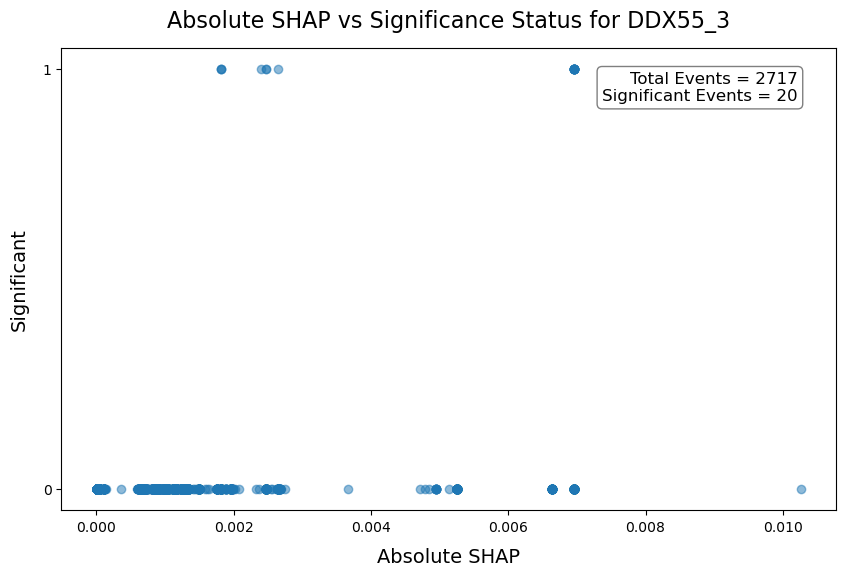

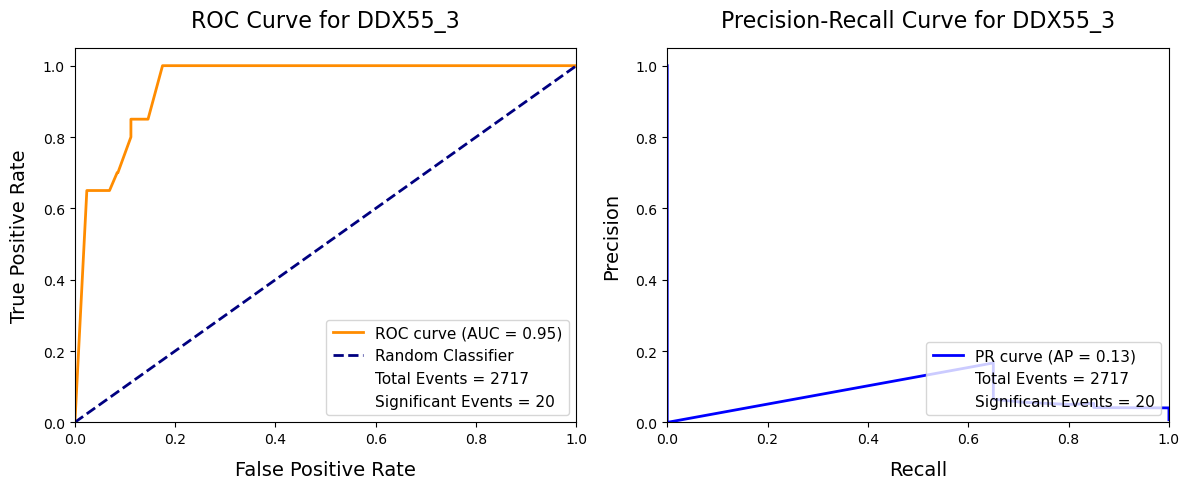

Processing: TIA1_1


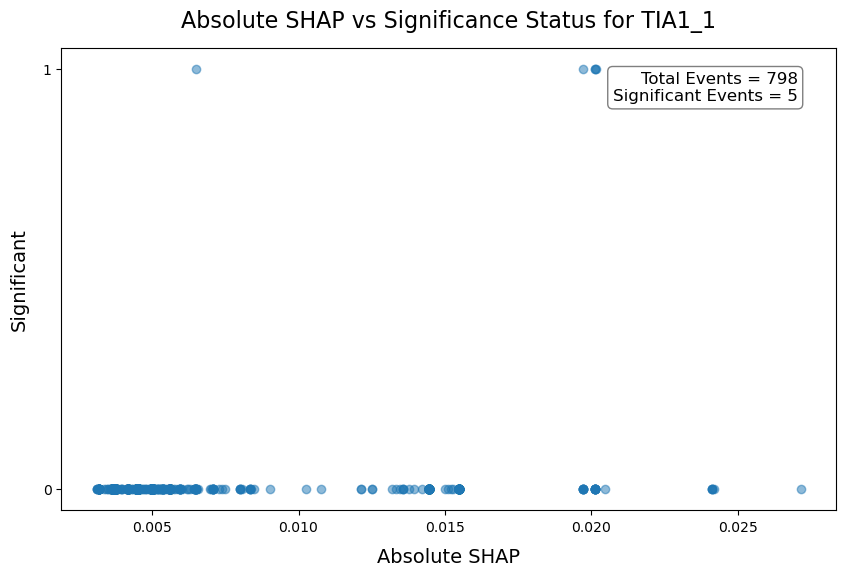

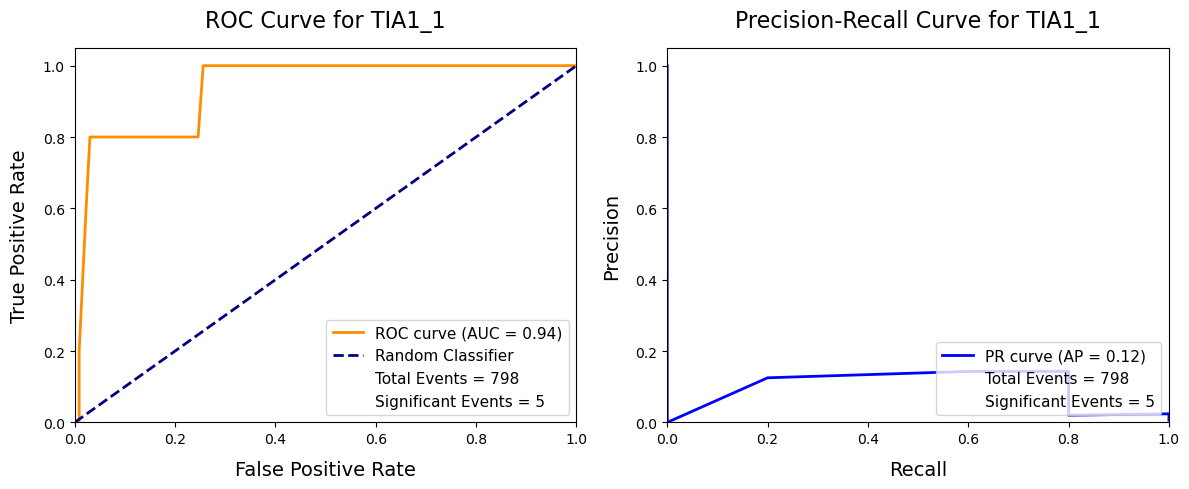

Processing: DDX55_1


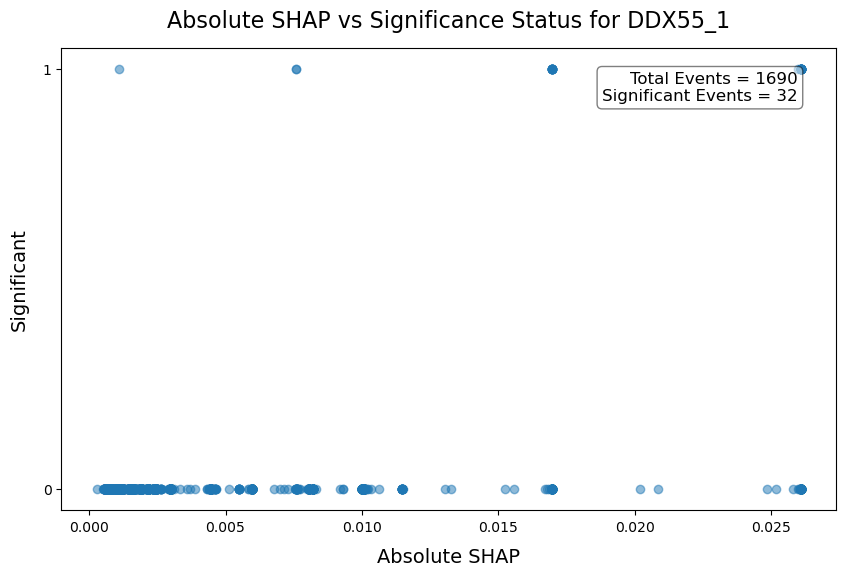

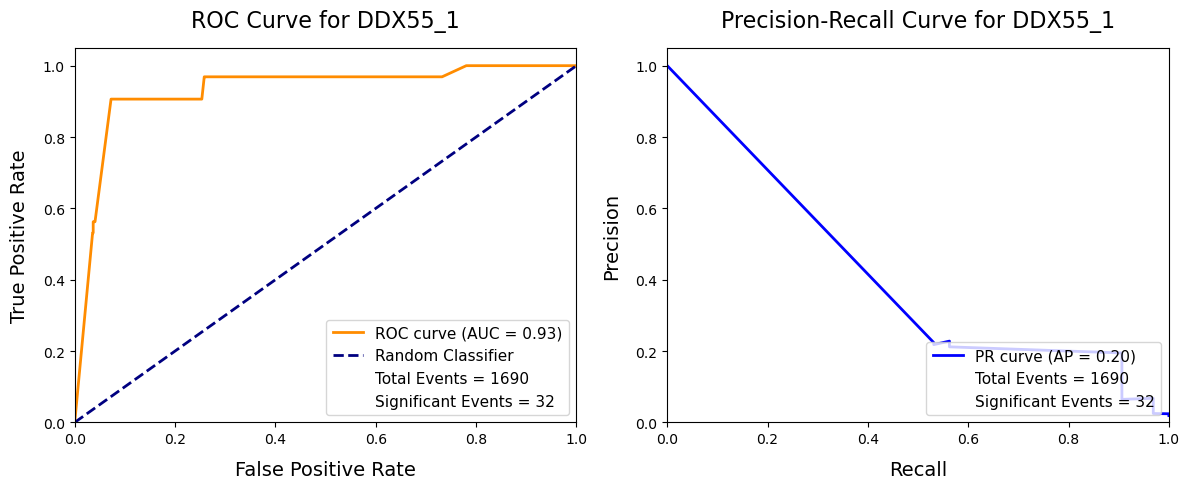

Processing: AGGF1_4


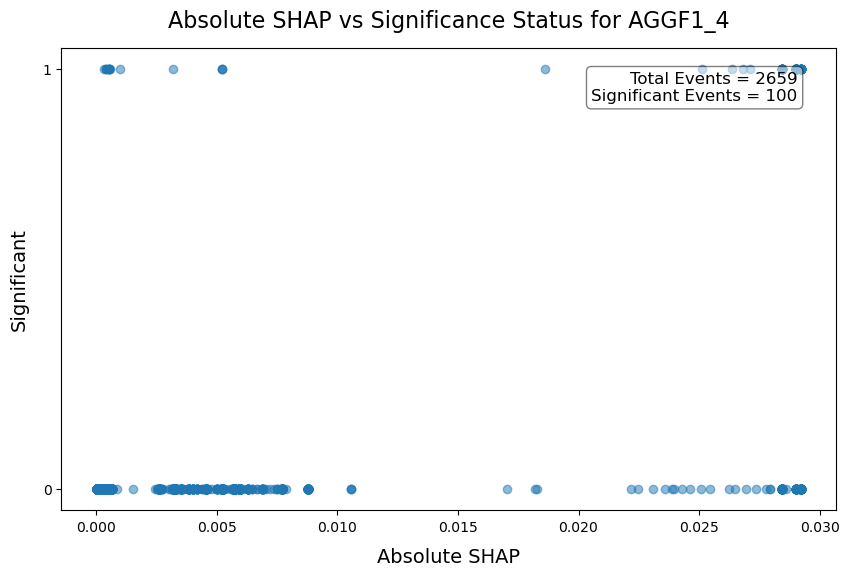

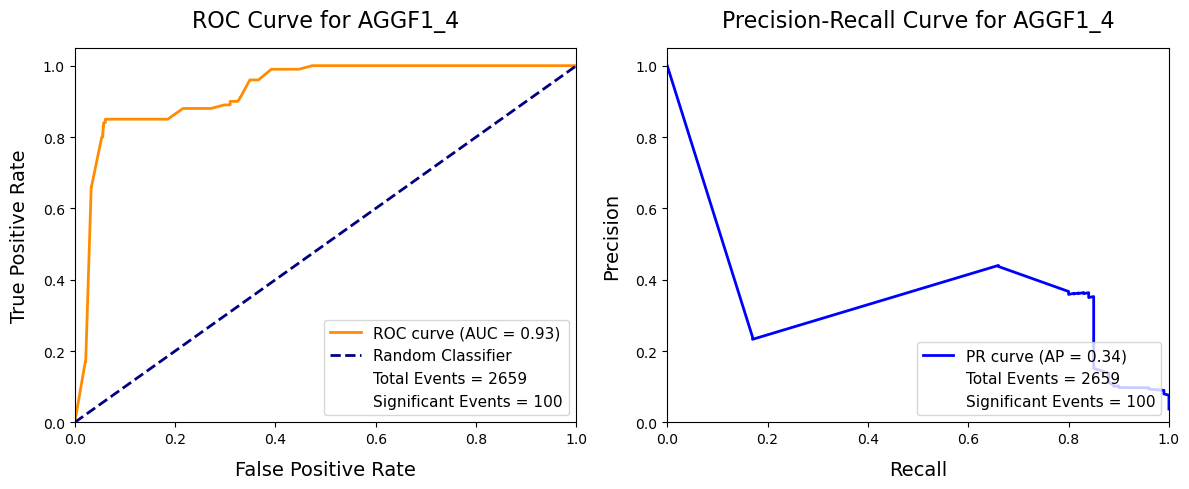

Processing: SFPQ_4


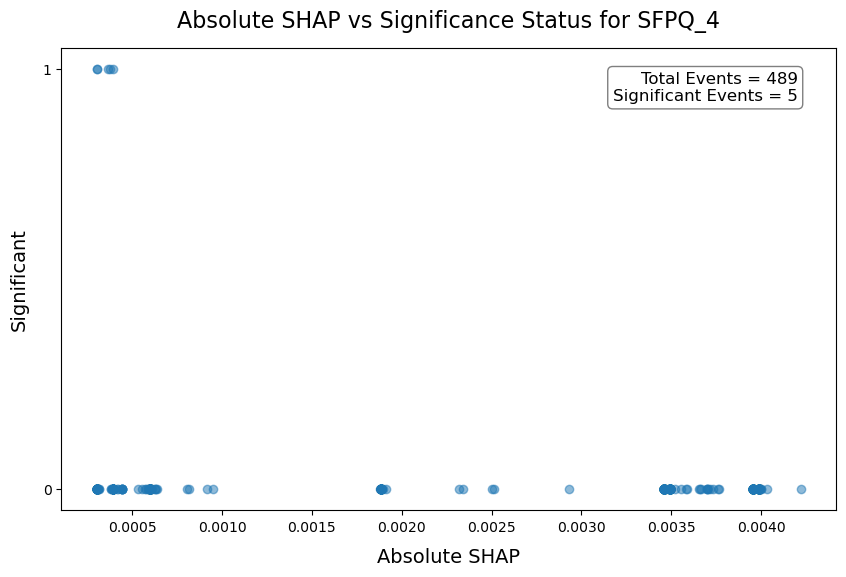

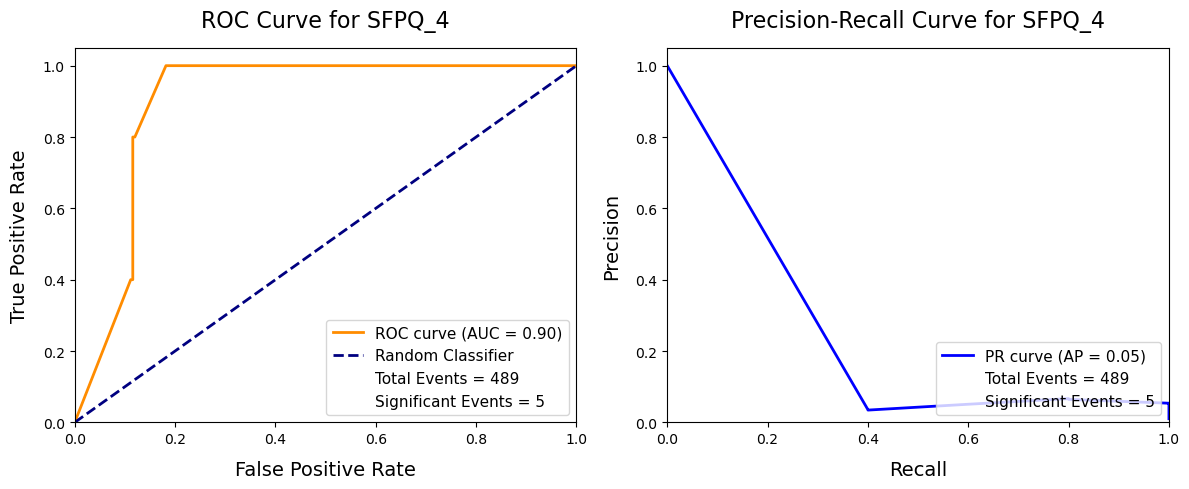


Final Results:
   feature     AUROC     AUPRC  total_events  num_significant
0  DDX55_3  0.948619  0.125019          2717               20
1   TIA1_1  0.936444  0.115522           798                5
2  DDX55_1  0.930394  0.197832          1690               32
3  AGGF1_4  0.927649  0.341205          2659              100
4   SFPQ_4  0.901240  0.048541           489                5


In [9]:
# Best ROCs
features = ["DDX55_3", "TIA1_1", "DDX55_1", "AGGF1_4", "SFPQ_4"]
results_df = plot_best_curves(features, HepG2_data, plot=True, save_dir='HepG2_ROC_plots')

Processing: AGGF1_4


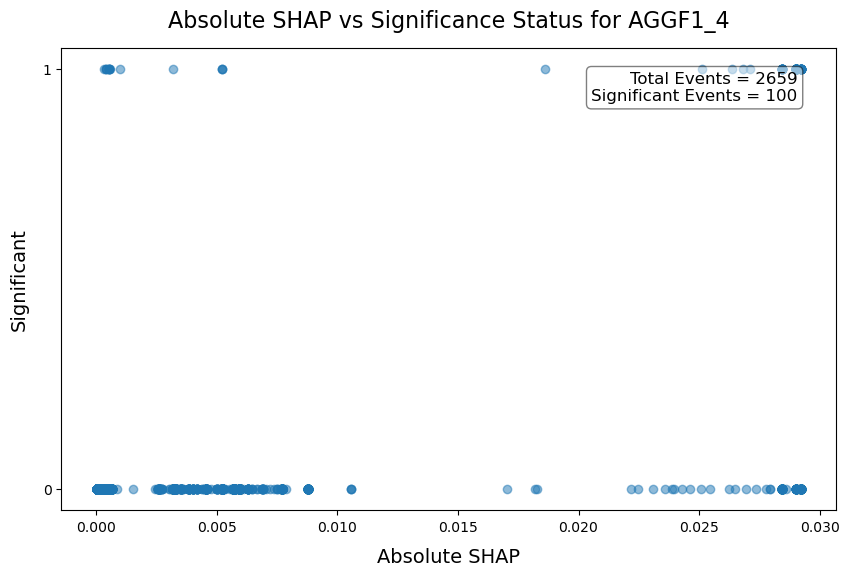

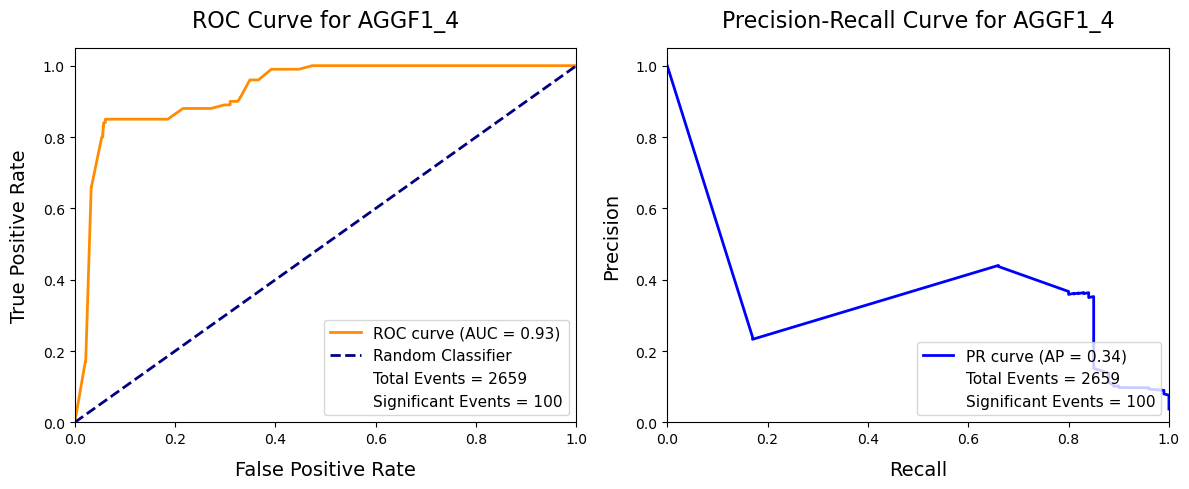

Processing: UPF1_3


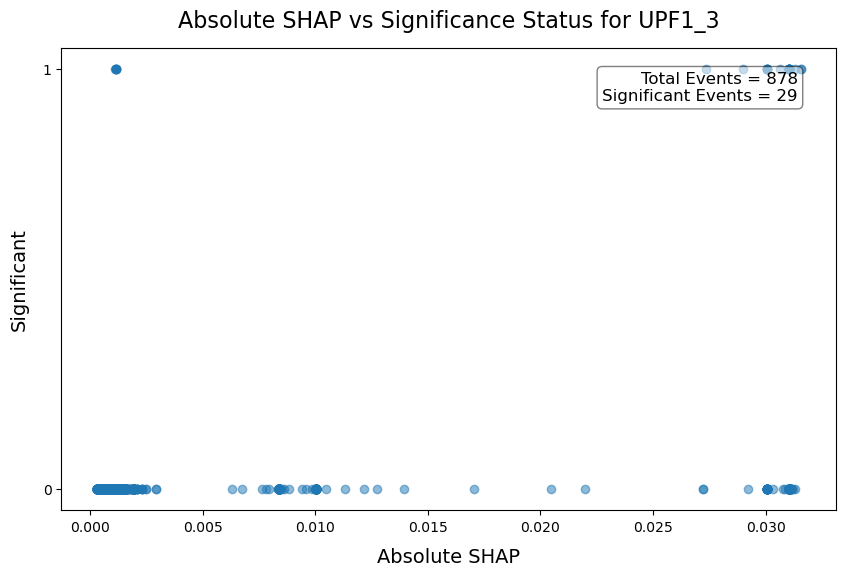

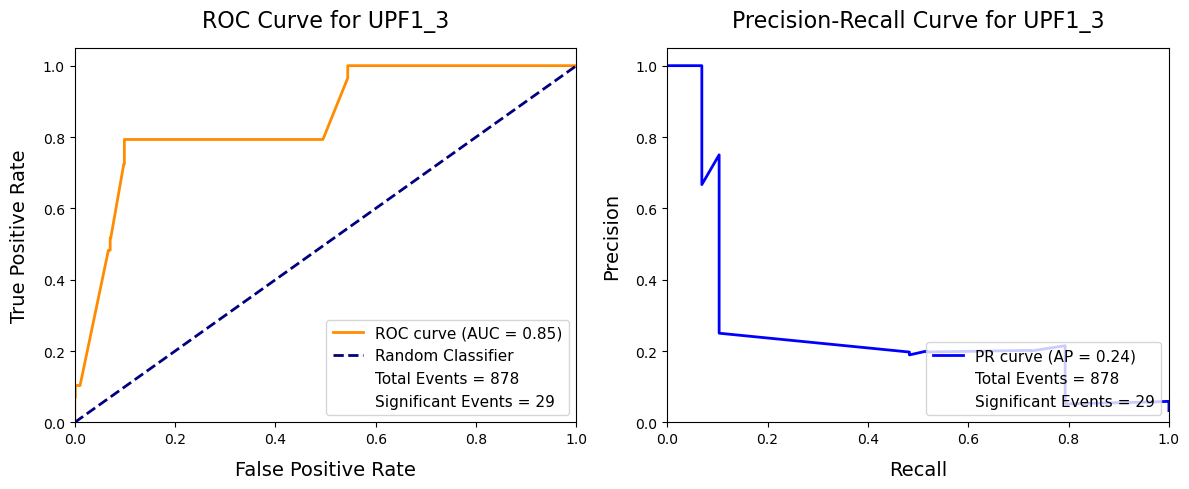

Processing: HNRNPA1_5


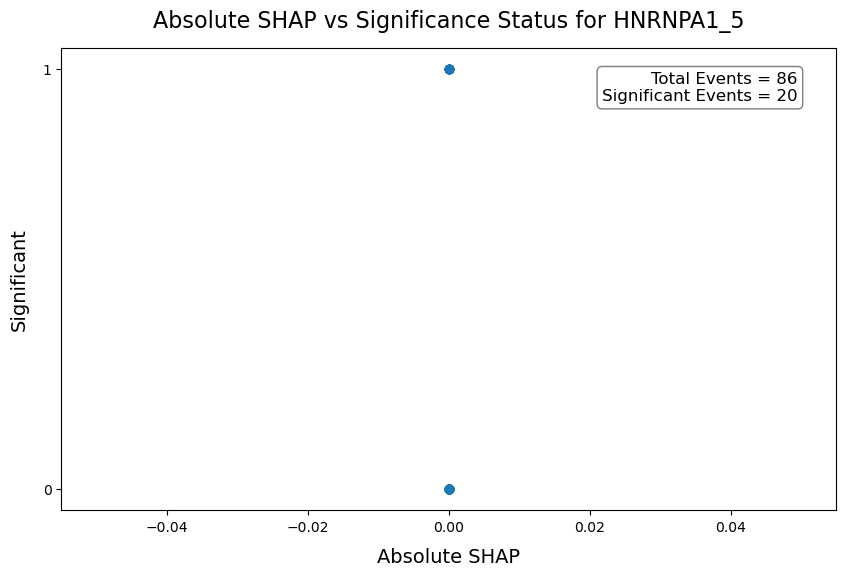

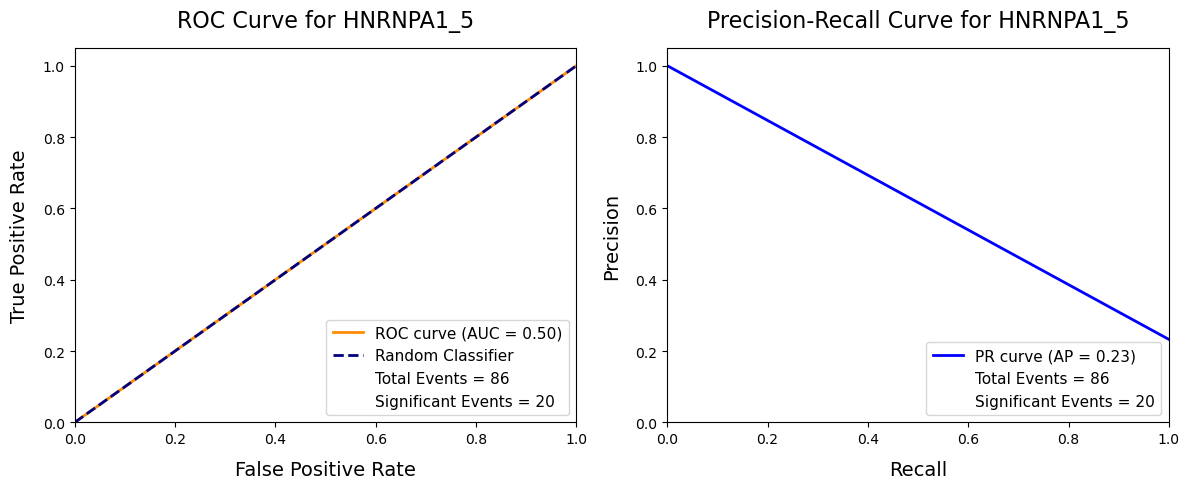

Processing: XRN2_6


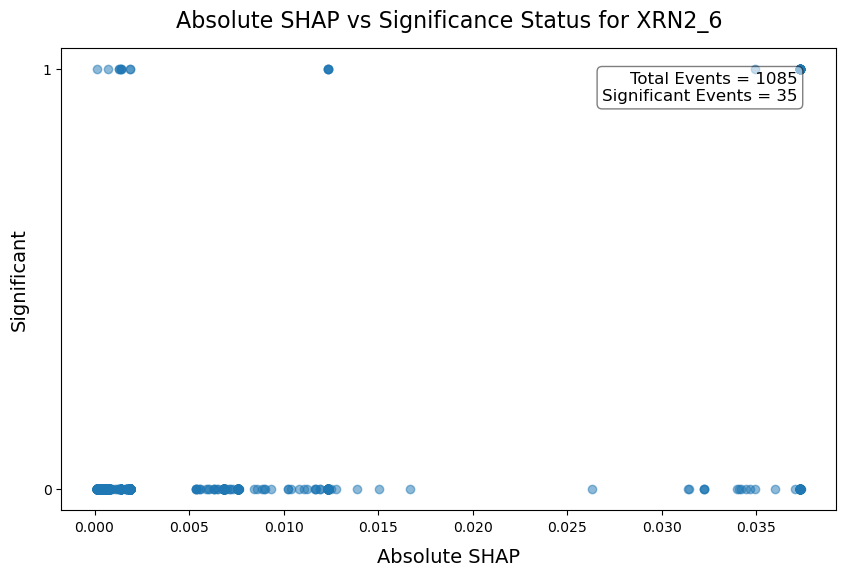

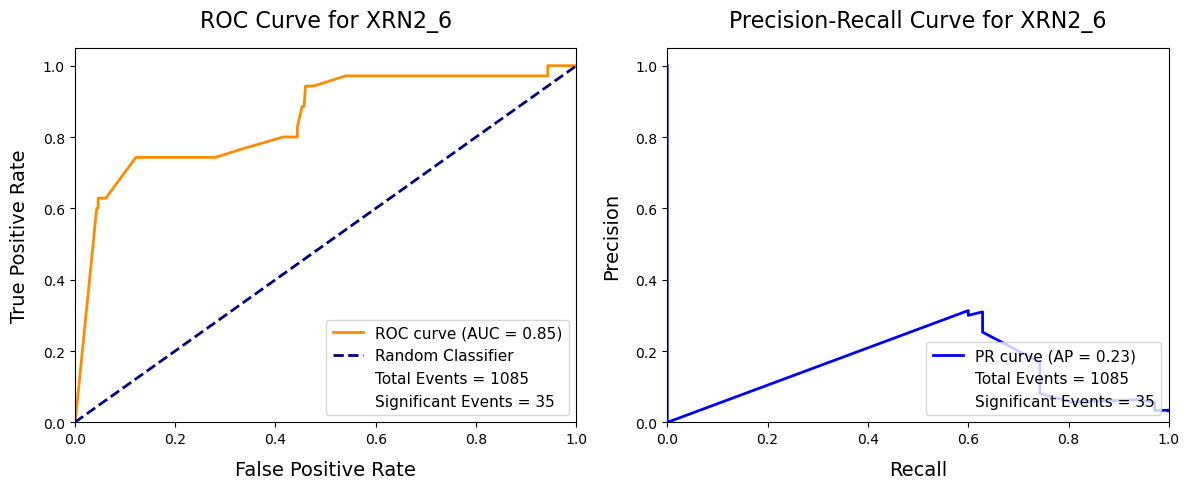

Processing: WDR43_3


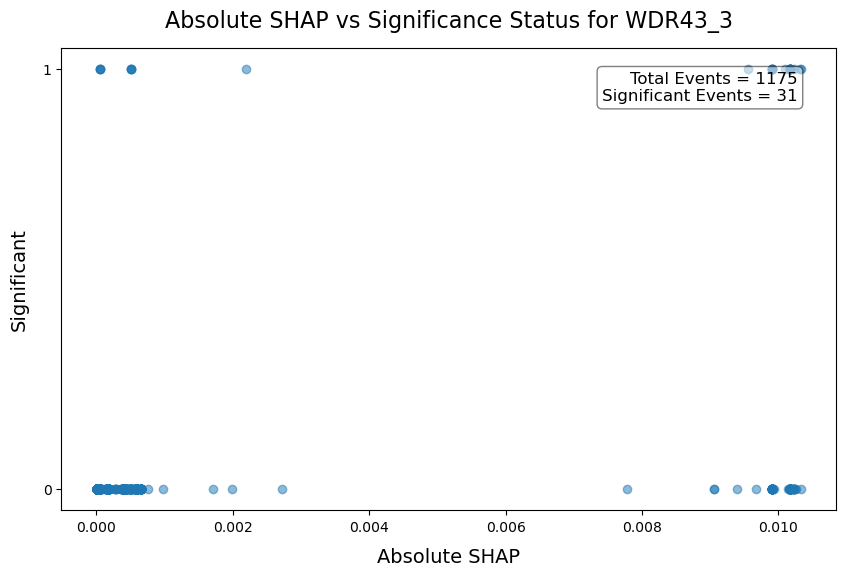

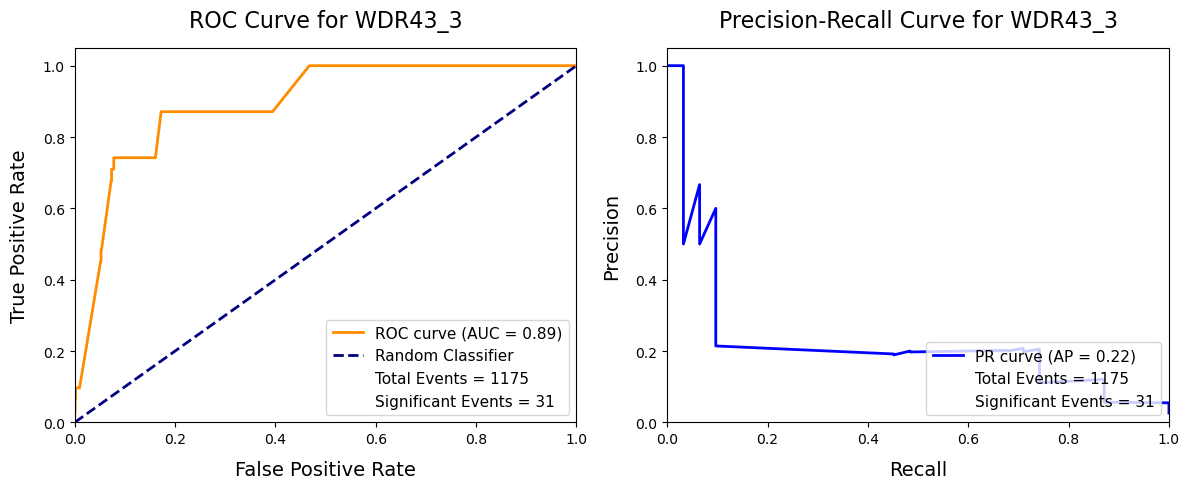


Final Results:
     feature     AUROC     AUPRC  total_events  num_significant
0    AGGF1_4  0.927649  0.341205          2659              100
1     UPF1_3  0.850087  0.244753           878               29
2  HNRNPA1_5  0.500000  0.232558            86               20
3     XRN2_6  0.848966  0.231329          1085               35
4    WDR43_3  0.893216  0.222643          1175               31


In [11]:
# Best PRCs
features = ["AGGF1_4", "UPF1_3", "HNRNPA1_5", "XRN2_6", "WDR43_3"]
results_df = plot_best_curves(features, HepG2_data, plot=True, save_dir='HepG2_PRC_plots')

## K562

In [12]:
# Read in HepG2 table
K562_big_data_path = get_path("K562")
K562_data = pl.read_ipc(K562_big_data_path)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [4]:
# Extract a list of all RBPs from the binding columns

# Get all column names that contain "binding"
binding_cols = [col for col in K562_data.columns if 'binding' in col]

# Extract protein names (everything before the first underscore)
protein_names = list(set([col.split('_')[0] for col in binding_cols]))

# Make a list of positions

positions = [1, 2, 3, 4, 5, 6]

['MATR3', 'HNRNPC', 'SSB', 'FAM120A', 'EIF4G2', 'MORC2', 'AATF', 'DDX43', 'LIN28B', 'MTPAP', 'QKI', 'DDX21', 'BUD13', 'FXR2', 'EIF3G', 'UTP3', 'EXOSC5', 'DDX1', 'PUM1', 'PRPF8', 'SBDS', 'SAFB', 'SMNDC1', 'HNRNPA1', 'EIF4E', 'FTO', 'CPEB4', 'WDR43', 'APOBEC3C', 'DDX3X', 'IGF2BP2', 'PUS1', 'ABCF1', 'EEF2', 'DDX6', 'HNRNPL', 'GNL3', 'NIPBL', 'DDX47', 'HLTF', 'IGF2BP1', 'TAF15', 'PCBP1', 'RBM22', 'FASTKD2', 'CPSF6', 'RPS6', 'ILF3', 'RNF187', 'LSM11', 'U2AF2', 'LARP7', 'TBRG4', 'LARP4', 'UTP18', 'FMR1', 'GPKOW', 'PABPC4', 'EXOSC10', 'DGCR8', 'TARDBP', 'AGGF1', 'SLBP', 'KHSRP', 'GRWD1', 'YWHAG', 'SLTM', 'YBX3', 'DDX51', 'PUM2', 'ZC3H11A', 'TRA2A', 'DDX55', 'GARS', 'XRN2', 'ADAT1', 'RBFOX2', 'NPM1', 'TIA1', 'GTF2F1', 'RPS3', 'SUPV3L1', 'METAP2', 'PHF6', 'HNRNPM', 'RPS11', 'NSUN2', 'DDX24', 'RBM15', 'AKAP8L', 'WRN', 'WDR3', 'DROSHA', 'KHDRBS1', 'DDX52', 'NONO', 'PPIL4', 'SRSF9', 'UCHL5', 'ZC3H8', 'FXR1', 'GEMIN5', 'ELAVL1', 'AARS', 'SND1', 'NOLC1', 'SF3B1', 'SRSF7', 'SAFB2', 'U2AF1', 'SDAD1', 

In [6]:
## Loop through each feature

# Initialize results dataframe
results_list = []

# Run through the loop for each protein at each position
for rbp in protein_names:
    for position in positions:
    
        print(f"Processing: {rbp}")
        print(f"Position: {position}")
    
        columns_to_keep = [
            "rMATS Event ID",
            f"{rbp}_{position}_binding",
            "FDR",
            "DeltaPSI",
            f"{rbp}_{position}_shap",
            "Sample Name"
        ]
    
        # Drop unnecessary columns
        rbp_data = K562_data.select(columns_to_keep)
    
        rbp_data_filtered = (
            rbp_data
            .filter(
                (pl.col("Sample Name").str.contains("KD", literal=True)) &
                (pl.col(f"{rbp}_{position}_binding") == 1)
            )
            .unique(subset=["rMATS Event ID"])
        )
        
        # Convert to pandas
        rbp_df = rbp_data_filtered.to_pandas()
    
        # Print to check
        # print(rbp_df)
        # Add a new column based on significance (significant if FDR <= 0.05 and abs dPSI >= 0.1
        rbp_df['Significant'] = np.where(
            (rbp_df['FDR'] <= 0.05) & (rbp_df['DeltaPSI'].abs() >= 0.1),
            1,
            0
        )
        
        # Count total events and significant events
        total_events = len(rbp_df)
        num_significant = rbp_df['Significant'].sum()
        
        # Skip if all events are not significant (all zeros in Significant column)
        if num_significant == 0:
            print(f"Skipping {rbp} at position {position}: No significant events")
            continue
    
        # Make training data
        smaller_df = rbp_df[[f'{rbp}_{position}_shap', 'Significant', 'rMATS Event ID']].copy()
        
        smaller_df['absolute_shap'] = smaller_df[f'{rbp}_{position}_shap'].abs()
        
        smaller_df = smaller_df.rename(columns={'rMATS Event ID': 'Event_ID'})
        
        smaller_df = smaller_df[['absolute_shap', 'Significant', 'Event_ID']]
    
        # Print to check
        print(smaller_df)
    
        # Training logistic regression model
        
        # Prepare data
        X = smaller_df[['absolute_shap']].values  # Features
        y = smaller_df['Significant'].values      # Target
        
        # Train a classifier on all data
        classifier = LogisticRegression()
        classifier.fit(X, y)
        
        # Get predicted probabilities for the same data
        y_pred_proba = classifier.predict_proba(X)[:, 1]  # Probability of class 1
    
        # Calculate ROC curve
        fpr, tpr, thresholds_roc = roc_curve(y, y_pred_proba)
        roc_auc = auc(fpr, tpr)
    
        # Calculate PRC
        precision, recall, thresholds_pr = precision_recall_curve(y, y_pred_proba)
        avg_precision = average_precision_score(y, y_pred_proba)
        
        # Store the results with event counts
        results_list.append({
            'feature': f'{rbp}_{position}',
            'AUROC': roc_auc,
            'AUPRC': avg_precision,
            'total_events': total_events,
            'num_significant': num_significant
        })
        
# Create final results dataframe
results_df = pd.DataFrame(results_list)
print("\nFinal Results:")
print(results_df)

Processing: HNRNPA1
Position: 1
Skipping HNRNPA1 at position 1: No significant events
Processing: HNRNPA1
Position: 2
Skipping HNRNPA1 at position 2: No significant events
Processing: HNRNPA1
Position: 3
     absolute_shap  Significant  Event_ID
0         0.000000            0      5877
1         0.000000            0      5753
2         0.000000            0      6279
3         0.001018            0     49204
4         0.000000            0      6130
..             ...          ...       ...
248       0.001018            0     49494
249       0.000000            0      6095
250       0.001018            0     49199
251       0.000000            0      6094
252       0.001018            0     48563

[253 rows x 3 columns]
Processing: HNRNPA1
Position: 4
Skipping HNRNPA1 at position 4: No significant events
Processing: HNRNPA1
Position: 5
Skipping HNRNPA1 at position 5: No significant events
Processing: HNRNPA1
Position: 6
Skipping HNRNPA1 at position 6: No significant events
Processing

In [ ]:
# Save and sort results

results_df.to_csv('v2_K562_auroc_auprc_results.csv', index=False)

results_df = results_df.sort_values(by=['AUROC', 'AUPRC'], ascending=[False, False])

results_df2 = results_df.sort_values(by=['AUPRC', 'AUROC'], ascending=[False, False])

Processing: SRSF9_4


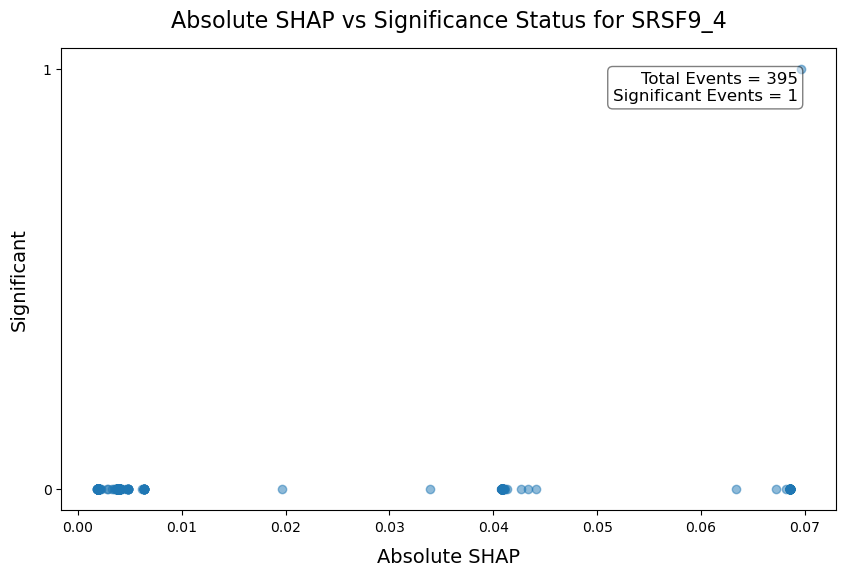

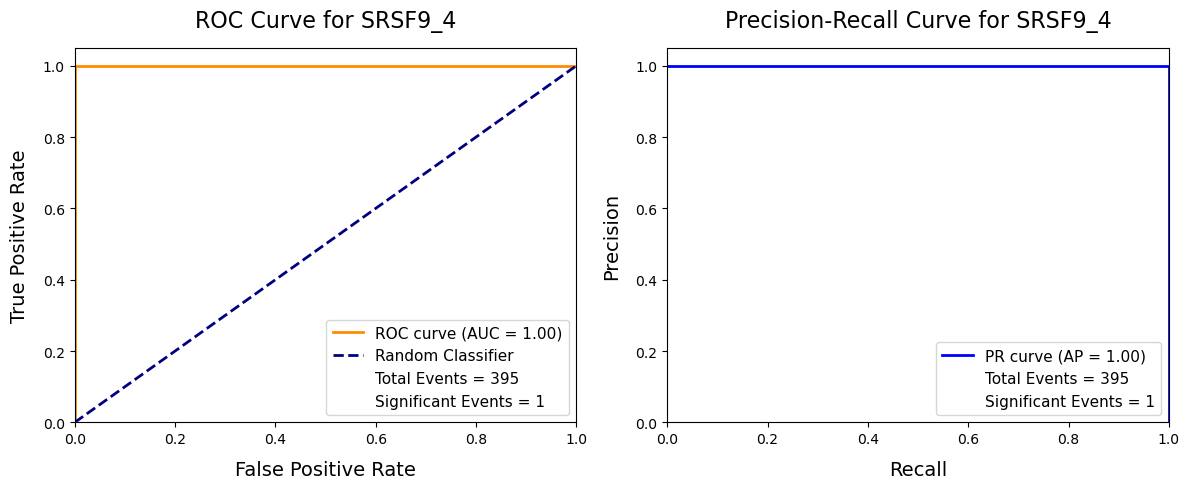

Processing: HLTF_4


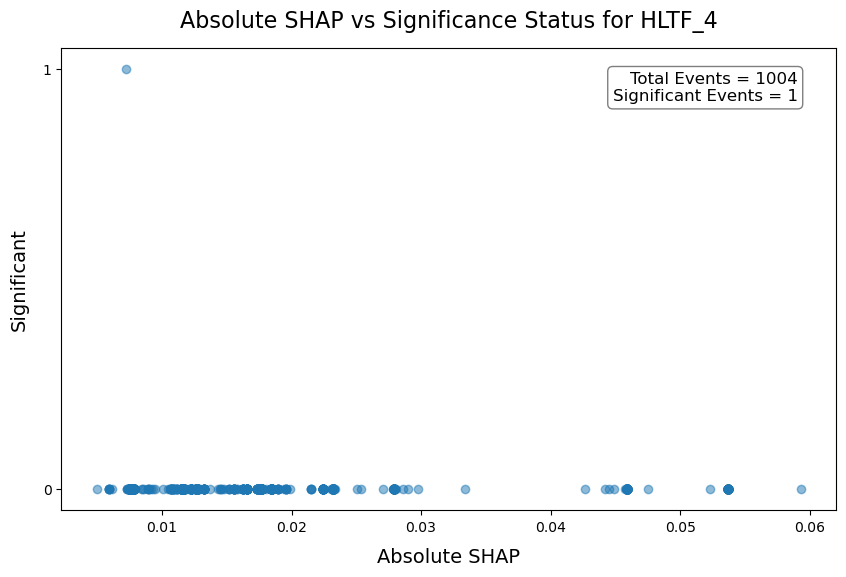

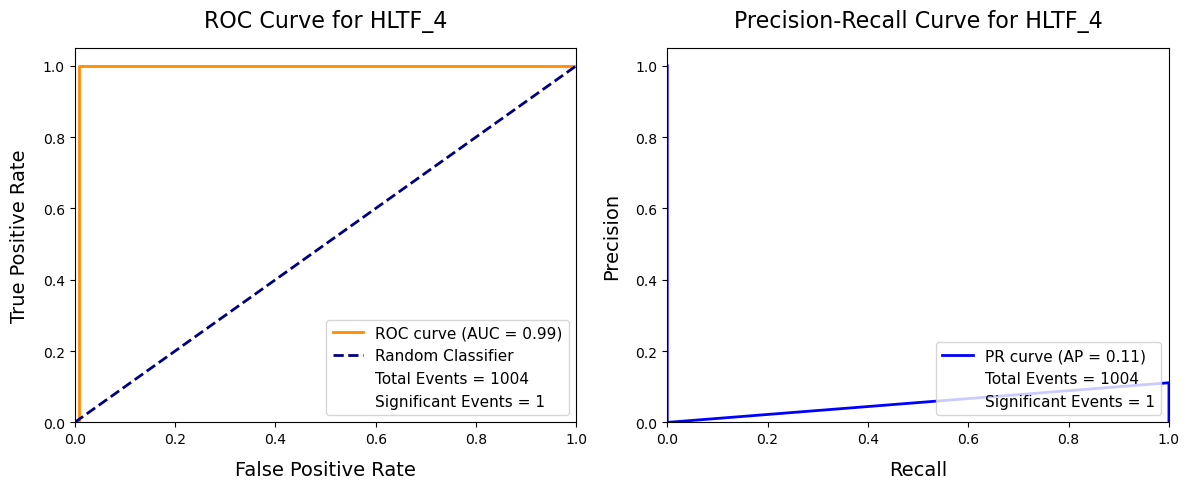

Processing: RPS6_6


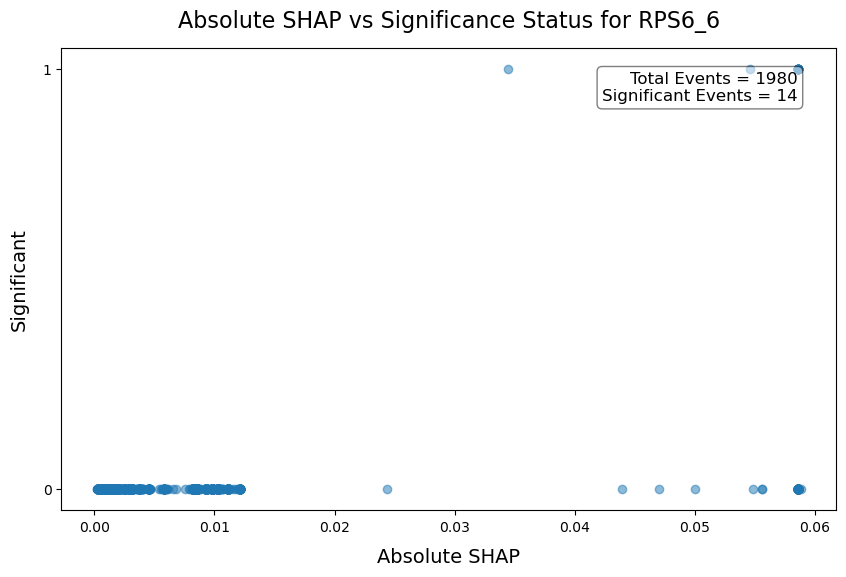

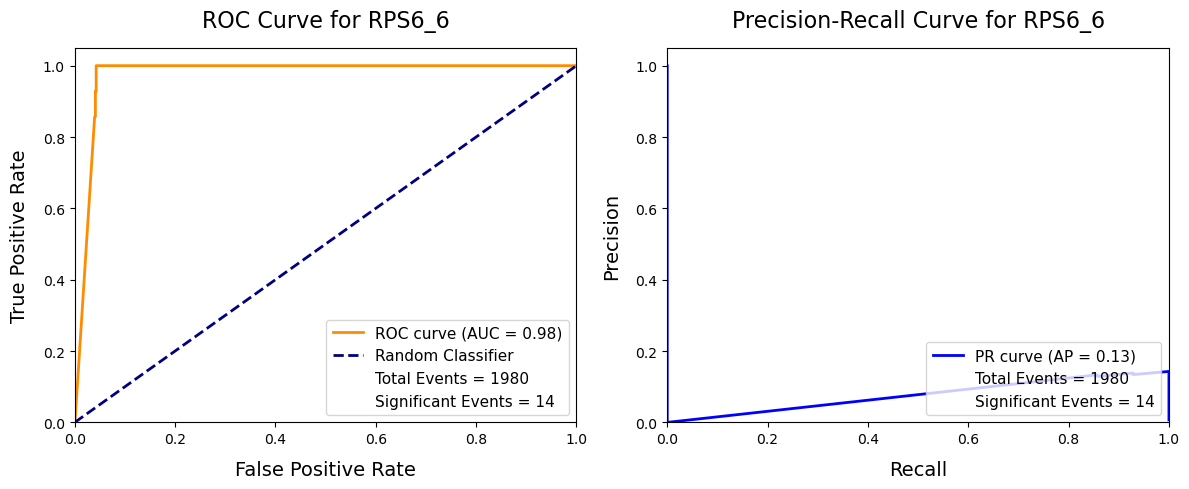

Processing: SSB_2


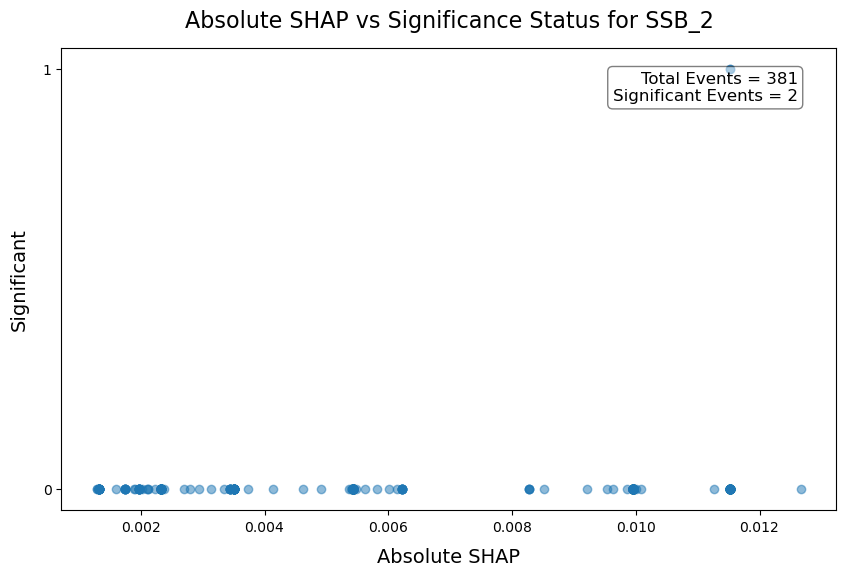

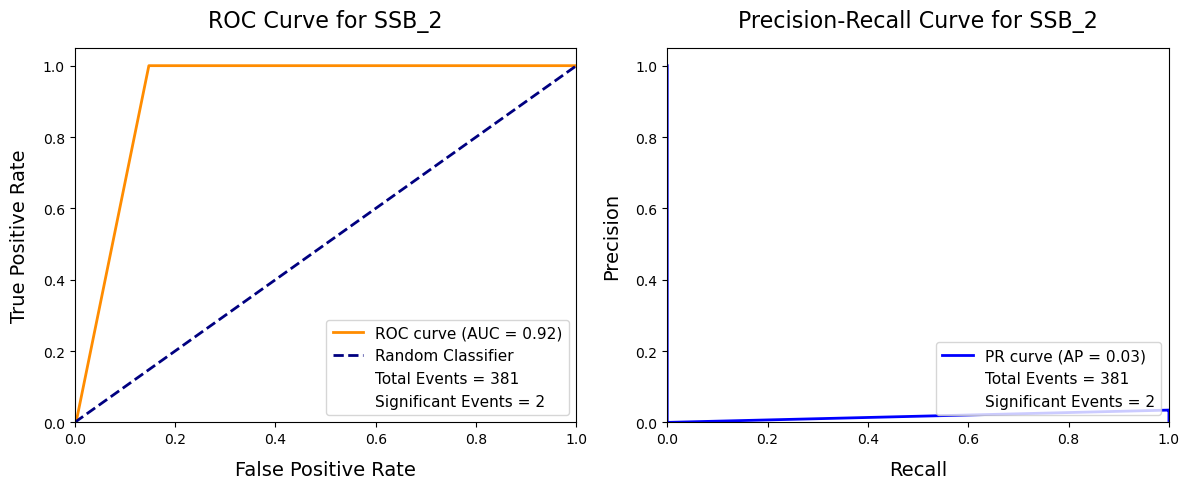

Processing: AARS_3


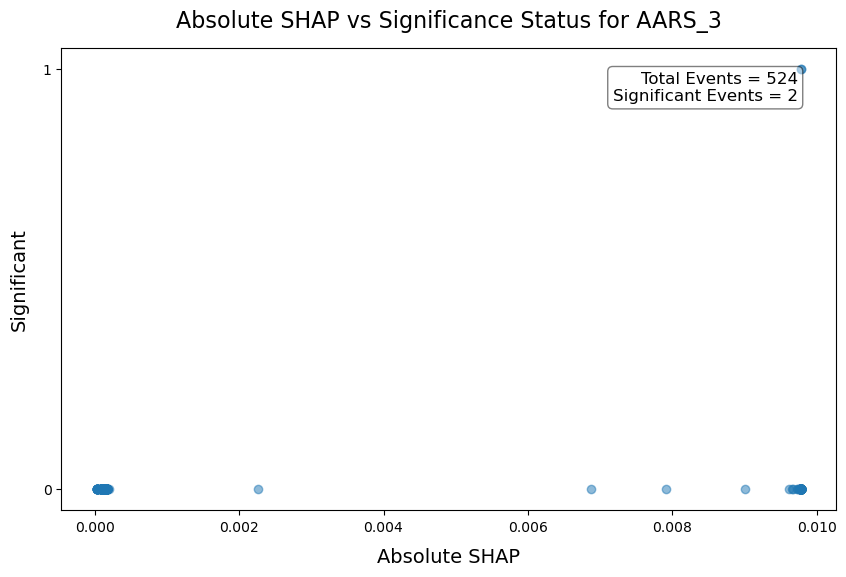

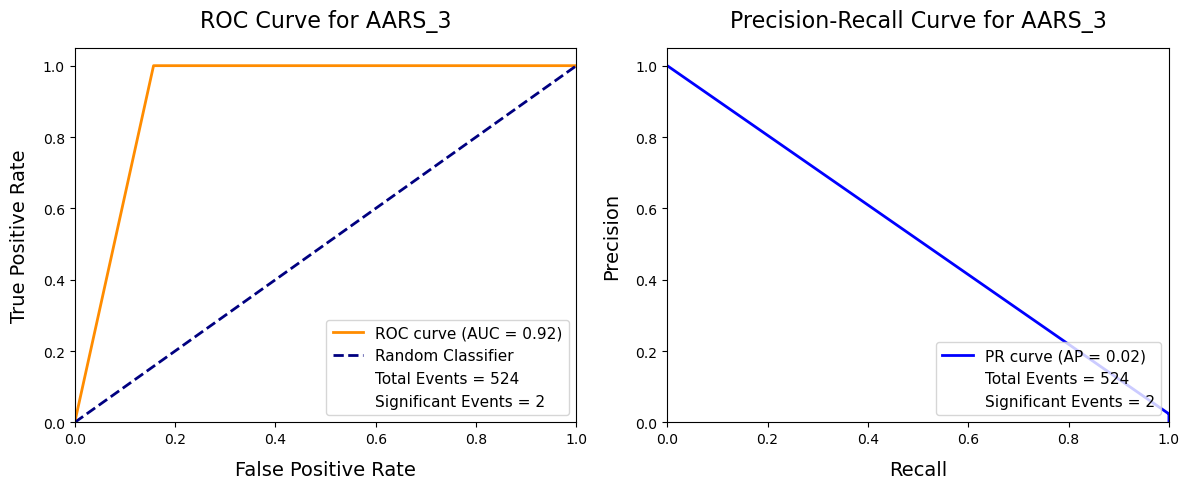


Final Results:
   feature     AUROC     AUPRC  total_events  num_significant
0  SRSF9_4  1.000000  1.000000           395                1
1   HLTF_4  0.992024  0.111111          1004                1
2   RPS6_6  0.976784  0.134368          1980               14
3    SSB_2  0.924802  0.034483           381                2
4   AARS_3  0.921456  0.023810           524                2


In [13]:
# Best ROCs
features = ["SRSF9_4", "HLTF_4", "RPS6_6", "SSB_2", "AARS_3"]
results_df = plot_best_curves(features, K562_data, plot=True, save_dir='K562_ROC_plots')

Processing: SRSF9_4


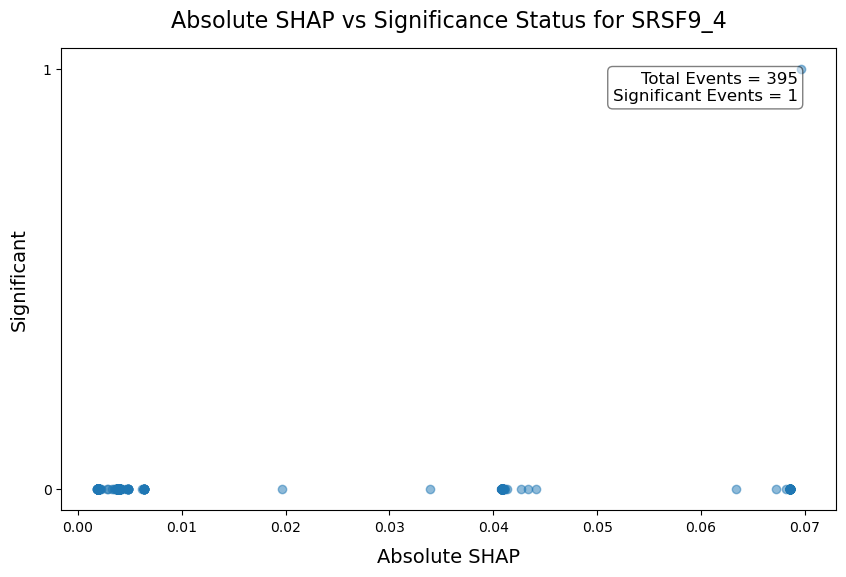

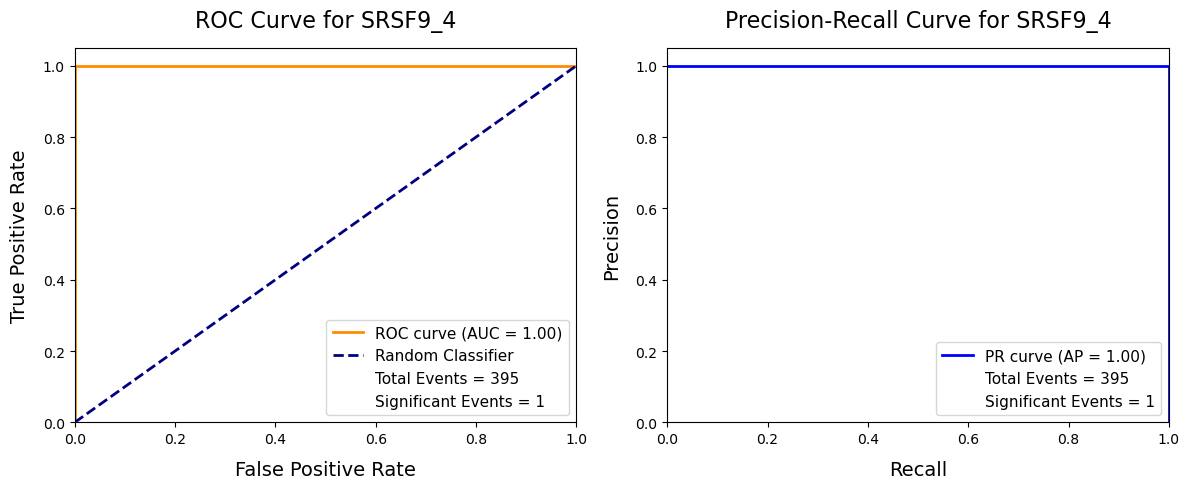

Processing: KHDRBS1_2


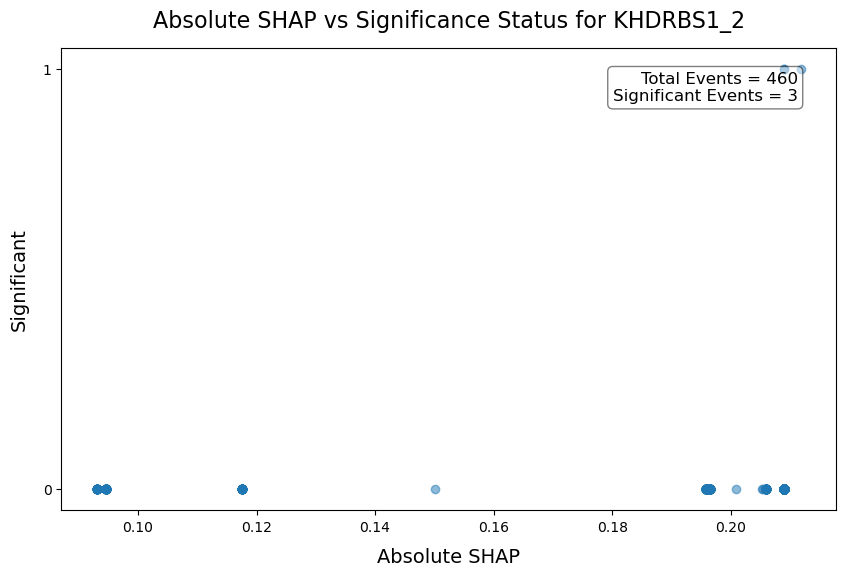

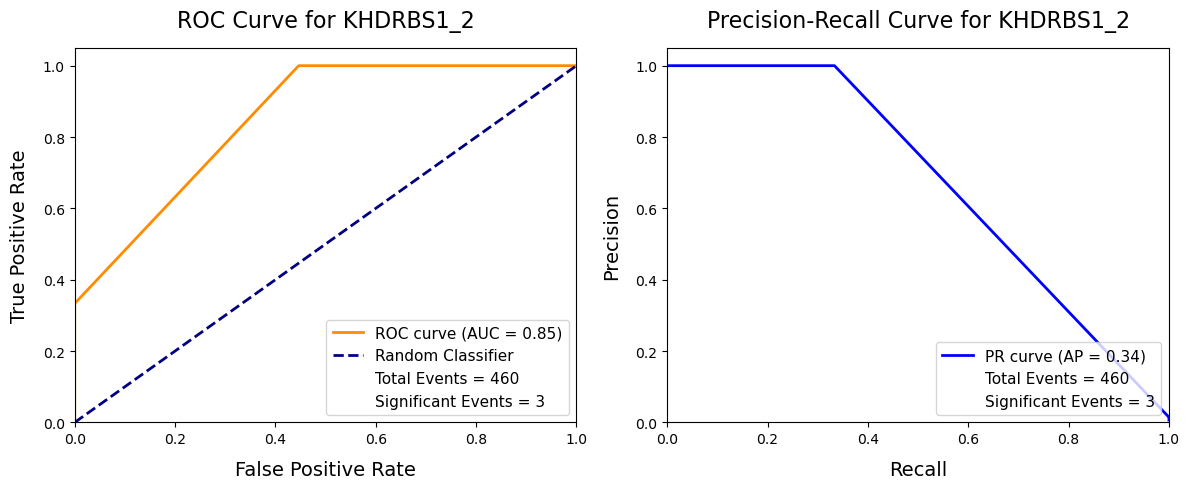

Processing: SAFB2_6


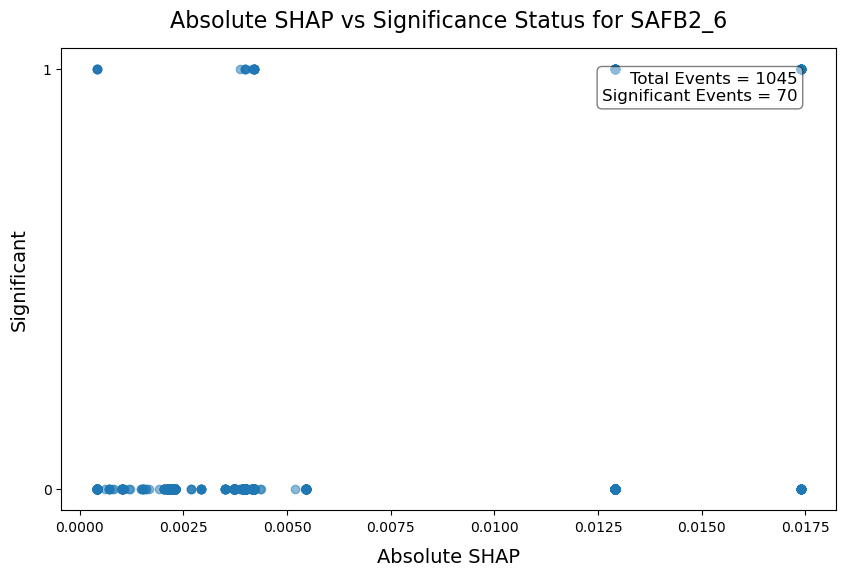

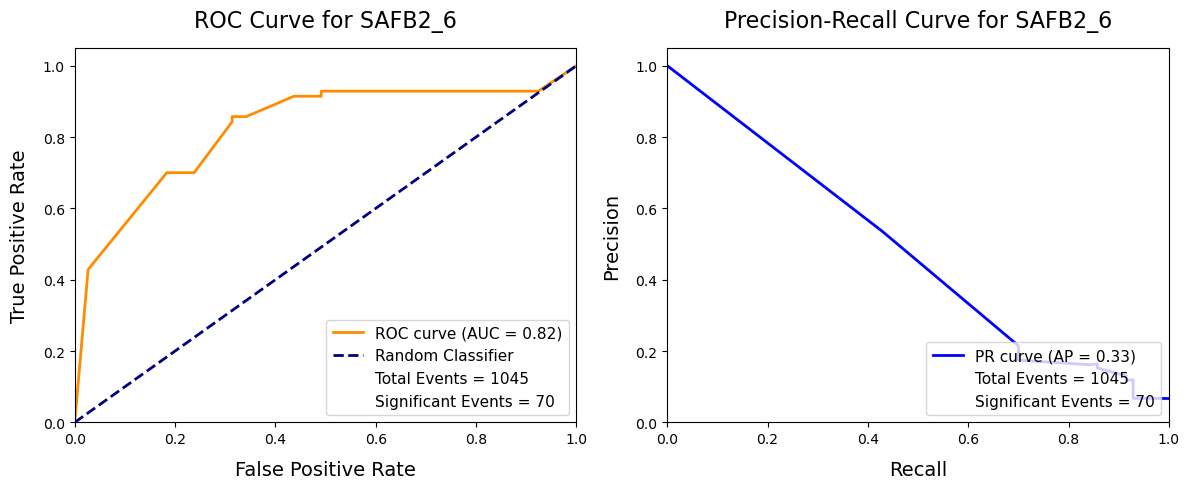

Processing: WRN_2


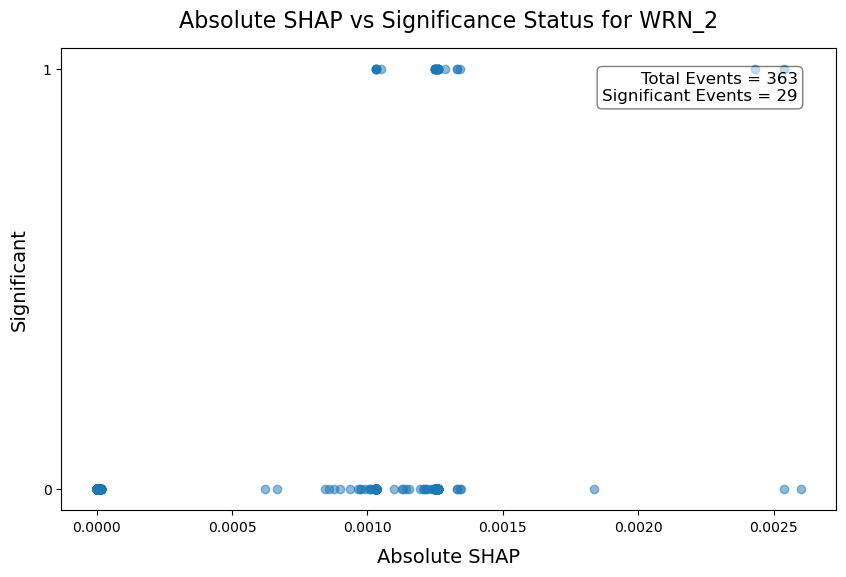

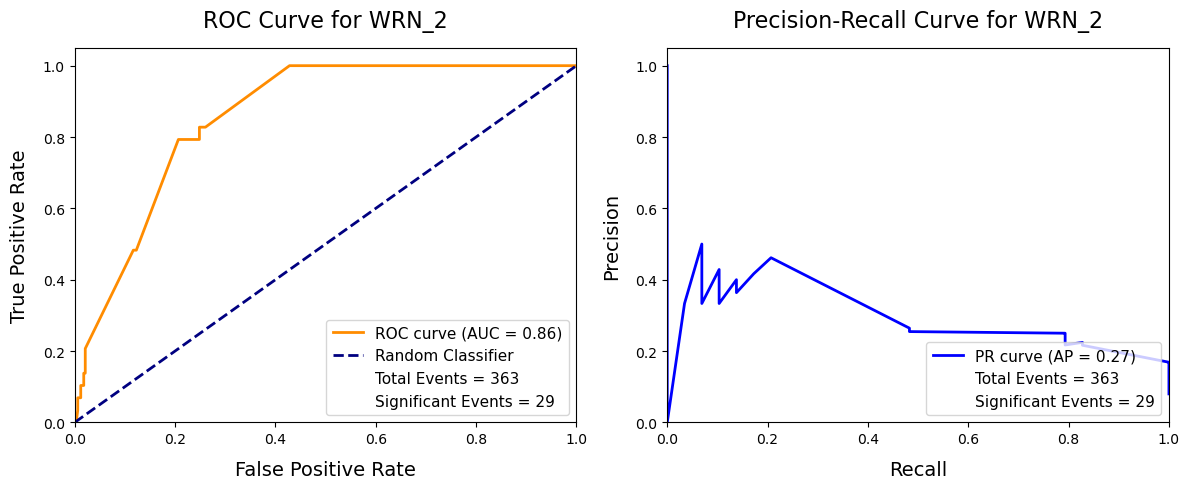

Processing: SERBP1_5


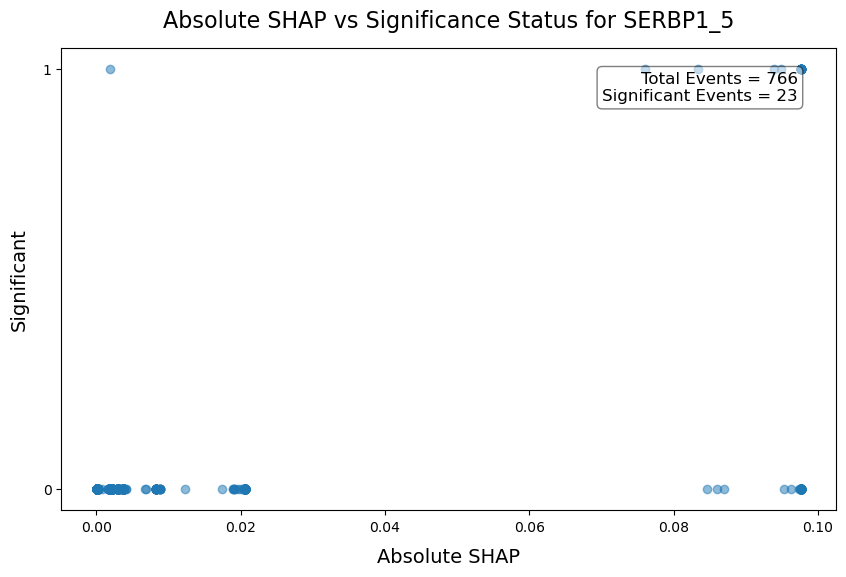

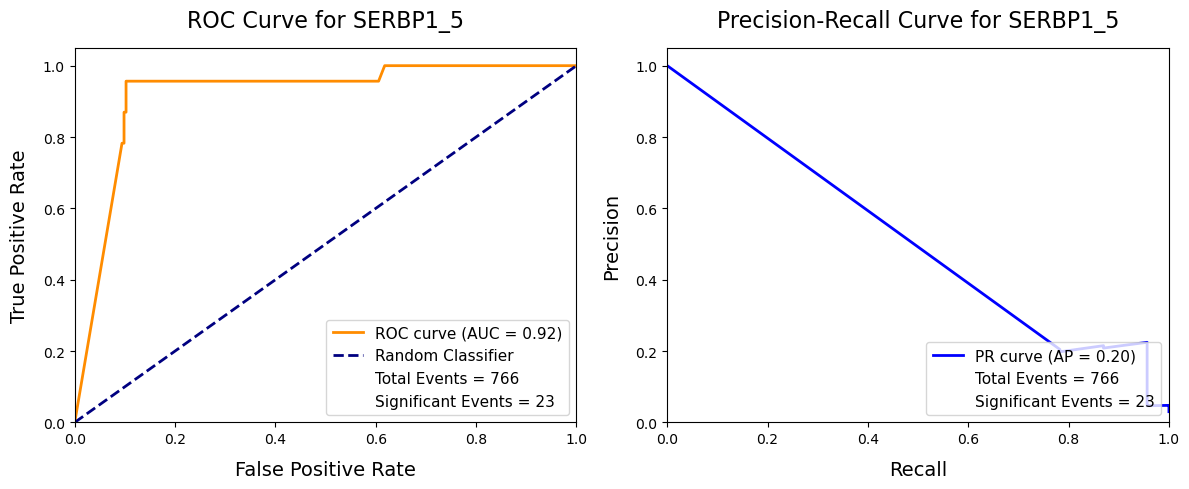


Final Results:
     feature     AUROC     AUPRC  total_events  num_significant
0    SRSF9_4  1.000000  1.000000           395                1
1  KHDRBS1_2  0.851204  0.342995           460                3
2    SAFB2_6  0.823875  0.327314          1045               70
3      WRN_2  0.859127  0.274850           363               29
4   SERBP1_5  0.919100  0.199656           766               23


In [14]:
# Best PRCs
features = ["SRSF9_4", "KHDRBS1_2", "SAFB2_6", "WRN_2", "SERBP1_5"]
results_df = plot_best_curves(features, K562_data, plot=True, save_dir='K562_PRC_plots')